In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_controller_csv(path, label):

    df = pd.read_csv(path)
    if label != "RBC":
        
        # Convert temperatures (stored with -273 offset)
        df["T_zone_C"] = df["T_zone"] - 273.15
        df["t_out_C"] = df["t_out"] - 273.15

        # Extract scalar action from "[value]"
        df["action_scalar"] = (
            df["action"]
            .astype(str)
            .str.replace("[", "", regex=False)
            .str.replace("]", "", regex=False)
            .astype(float)
        )

        # Incremental energy (useful diagnostically)
        df["energy_step"] = df["energy_kWh"].diff().fillna(0.0)

        # Time index
        df["time"] = np.arange(len(df))

        # Controller label
        df["controller"] = label
    else:
        # Time index
        df["time"] = np.arange(len(df))

        # Controller label
        df["controller"] = label
    return df


def plot_indoor_temperature(dfs, comfort_low=21, comfort_high=24):
    plt.figure(figsize=(6, 4))

    for df in dfs:
        label = df["controller"].iloc[0]
        plt.plot(df["time"], df["T_zone_C"], label=label)

    plt.axhline(comfort_low, linestyle="--")
    plt.axhline(comfort_high, linestyle="--")

    plt.xlabel("Time step")
    plt.ylabel("Indoor temperature [°C]")
    plt.title("Indoor Temperature Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_external_temperature(dfs):
    plt.figure(figsize=(10, 4))

    for df in dfs:
        label = df["controller"].iloc[0]
        plt.plot(df["time"], df["t_out_C"], label=label)

    plt.xlabel("Time step")
    plt.ylabel("Outdoor temperature [°C]")
    plt.title("Outdoor Temperature Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actions(dfs):
    plt.figure(figsize=(10, 4))

    for df in dfs:
        label = df["controller"].iloc[0]
        plt.plot(df["time"], df["action_scalar"], label=label)

    plt.xlabel("Time step")
    plt.ylabel("Action")
    plt.title("Control Action Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cumulative_energy(dfs):
    plt.figure(figsize=(10, 4))

    for df in dfs:
        label = df["controller"].iloc[0]
        plt.plot(df["time"], df["energy_kWh"], label=label)

    plt.xlabel("Time step")
    plt.ylabel("Cumulative energy [kWh]")
    plt.title("Cumulative Energy Consumption")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cumulative_discomfort(dfs):
    plt.figure(figsize=(10, 4))

    for df in dfs:
        label = df["controller"].iloc[0]
        plt.plot(df["time"], df["discomfort"], label=label)

    plt.xlabel("Time step")
    plt.ylabel("Thermal discomfort [°C·h]")
    plt.title("Cumulative Thermal Discomfort")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_summary_table(dfs):
    print("\nController Performance Summary")
    print("-" * 50)

    for df in dfs:
        label = df["controller"].iloc[0]
        total_energy = df["energy_kWh"].iloc[-1]
        total_discomfort = df["discomfort"].iloc[-1]

        print(
            f"{label:15s} | "
            f"Energy: {total_energy:8.2f} kWh | "
            f"Discomfort: {total_discomfort:8.2f} °C·h"
        )

def denormalize(df, bounds):
    """
    De-normalization of DataFrame columns from [-1, 1].

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with normalized columns
    bounds : dict
        {column_name: (min, max)} in original physical units
    """
    for col, (x_min, x_max) in bounds.items():
        df[col] = 0.5 * (df[col] + 1.0) * (x_max - x_min) + x_min

def normalize(df, bounds):
    """
    normalizer in case I de-normalize twice by accident
    """
    for col, (x_min, x_max) in bounds.items():
        df[col] = 2.0 * (df[col] - x_min) / (x_max - x_min) - 1.0
        

In [3]:
df = pd.read_csv("DQN_Single_Switch\Testing\DQN_switch_1_27_25.csv")

bounds = {
    "T_zone": (273,324),
    "t_out": (257,305),
    "Psol_Wm2": (0, 862),
}

denormalize(
    df,
    bounds=bounds
)
df.to_csv("DQN_Single_Switch\Testing\DQN_switch_1_27_25_d.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:13: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:13: SyntaxWarning: invalid escape sequence '\T'
C:\Users\irmak\AppData\Local\Temp\ipykernel_19328\3402399072.py:1: SyntaxWarning: invalid escape sequence '\T'
  df = pd.read_csv("DQN_Single_Switch\Testing\DQN_switch_1_27_25.csv")
C:\Users\irmak\AppData\Local\Temp\ipykernel_19328\3402399072.py:13: SyntaxWarning: invalid escape sequence '\T'
  df.to_csv("DQN_Single_Switch\Testing\DQN_switch_1_27_25_d.csv", index=False)


## DQN SWITCH

<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
C:\Users\irmak\AppData\Local\Temp\ipykernel_19328\4277785116.py:3: SyntaxWarning: invalid escape sequence '\T'
  load_controller_csv("DQN_Single_Switch\Testing\DQN_switch_1_6_25_d.csv", "DQN_6_25"),
C:\Users\irmak\AppData\Local\Temp\ipykernel_19328\4277785116.py:4: SyntaxWarning: invalid escape sequence '\T'
  load_controller_csv("DQN_Single_Switch\Testing\DQN_switch_1_6_50_d.csv", "DQN_6_50"),
C:\Users\irmak\AppData\Local\Temp\ipykernel_19328\4277785116.py:5: SyntaxWarning: invalid escape sequence '\T'
  load_controller_csv("DQN_Single_Switch\Testing\DQN_switch_1_27_25_d.csv", "DQN_27_25"),


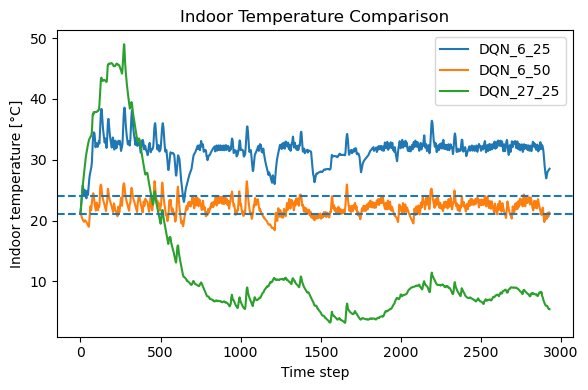

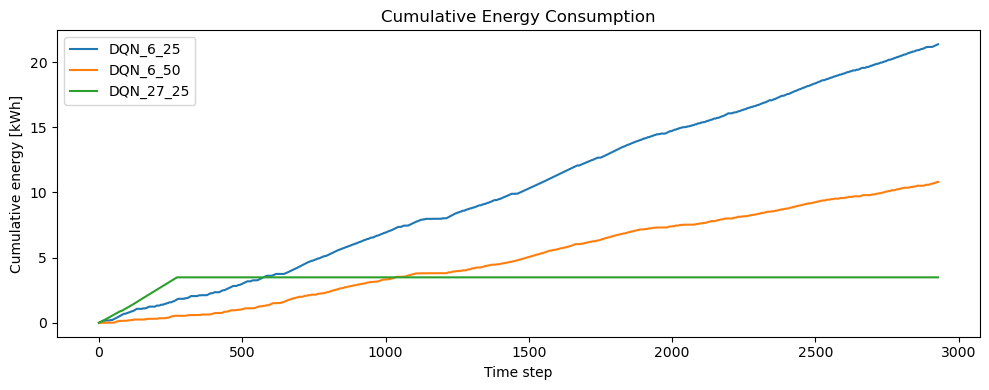

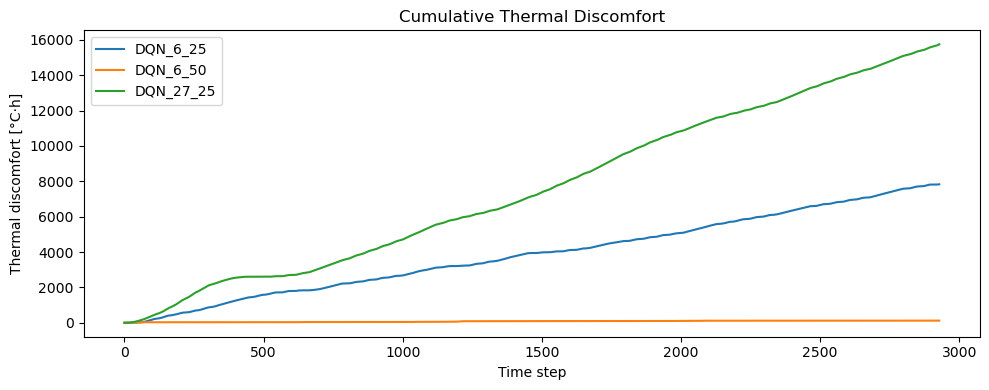

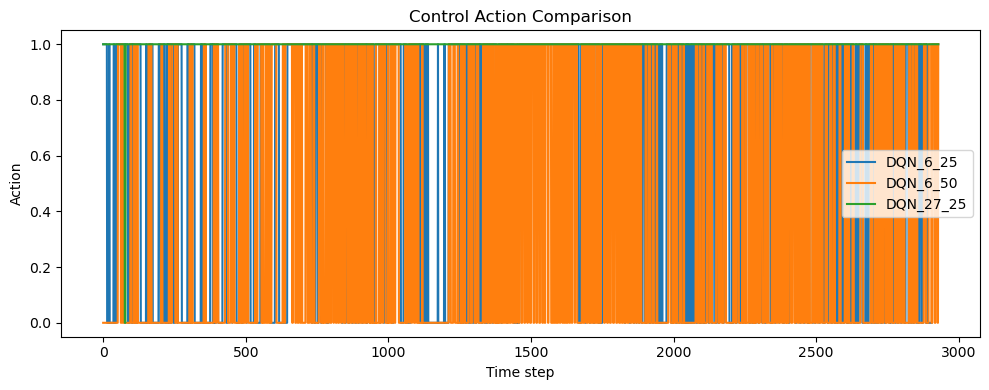


Controller Performance Summary
--------------------------------------------------
DQN_6_25        | Energy:    21.37 kWh | Discomfort:  7834.33 °C·h
DQN_6_50        | Energy:    10.81 kWh | Discomfort:   122.37 °C·h
DQN_27_25       | Energy:     3.49 kWh | Discomfort: 15753.17 °C·h


In [5]:
# DQN Switch 27 weeks 50 direct RL 50 planning
dfs = [
    load_controller_csv("DQN_Single_Switch\Testing\DQN_switch_1_6_25_d.csv", "DQN_6_25"),
    load_controller_csv("DQN_Single_Switch\Testing\DQN_switch_1_6_50_d.csv", "DQN_6_50"),
    load_controller_csv("DQN_Single_Switch\Testing\DQN_switch_1_27_25_d.csv", "DQN_27_25"),
    #load_controller_csv("DQN_switch_1_27_50_normalized.csv", "DQN_S_27"),
    #load_controller_csv("DynaPINN_27_50_100steps_denorm.csv", "Dyna-pinn-100"),
    #load_controller_csv("DynaPINN_27_50_100_denorm.csv", "Dyna-pinn-100"),
    #load_controller_csv("DDQ_RC_27_50_100steps_denorm.csv", "DDQ-RC-100"),
    #load_controller_csv("DDQ_NN_27_50_100steps_denorm.csv", "DDQ-NN-100"),
    #load_controller_csv("DQN_switch_1_27_50_normalized.csv", "DQN_S_27_50"),
    #load_controller_csv("DQN_switch_1_6_50_normalized.csv", "DQN_S_50"),
    #load_controller_csv("DQN_switch_1_6_25_normalized.csv", "DQN_S"),
    #load_controller_csv("rbc_single_switch.csv", "RBC"),
]

plot_indoor_temperature(dfs)
#
plot_cumulative_energy(dfs)
plot_cumulative_discomfort(dfs)
plot_actions(dfs)
print_summary_table(dfs)

In [6]:
# DQN Switch 27 weeks 50 direct RL 50 planning
dfs = [
    load_controller_csv("DQN_switch_1_27_50_r_normalized.csv", "DQN_S_27_r"),
    #load_controller_csv("DQN_switch_1_27_50_normalized.csv", "DQN_S_27"),
    load_controller_csv("DynaPINN_27_50_50steps_denorm.csv", "Dyna-pinn"),
    #load_controller_csv("DynaPINN_27_50_100_denorm.csv", "Dyna-pinn-100"),
    load_controller_csv("DDQ_RC_27_50_50steps_denorm.csv", "DDQ-RC"),
    load_controller_csv("DDQ_NN_27_50_50steps_denorm.csv", "DDQ-NN"),
    #load_controller_csv("DQN_switch_1_27_50_normalized.csv", "DQN_S_27_50"),
    #load_controller_csv("DQN_switch_1_6_50_normalized.csv", "DQN_S_50"),
    #load_controller_csv("DQN_switch_1_6_25_normalized.csv", "DQN_S"),
    #load_controller_csv("rbc_single_switch.csv", "RBC"),
]

plot_indoor_temperature(dfs)
#
plot_cumulative_energy(dfs)
plot_cumulative_discomfort(dfs)
plot_actions(dfs)
print_summary_table(dfs)

FileNotFoundError: [Errno 2] No such file or directory: 'DQN_switch_1_27_50_r_normalized.csv'

In [ ]:
# DQN Switch 27 weeks 50 direct RL 100 planning
dfs = [
    load_controller_csv("DQN_switch_1_27_50_r_normalized.csv", "DQN_S_27"),
    #load_controller_csv("DQN_switch_1_27_50_normalized.csv", "DQN_S_27"),
    #load_controller_csv("DynaPINN_27_50_final_normalized.csv", "Dyna-pinn"),
    #load_controller_csv("DDQ_RC_27_50_final_denorm.csv", "DDQ-RC"),
    load_controller_csv("DDQ_NN_27_50_100_denorm.csv", "DDQ-NN"),
    #load_controller_csv("DQN_switch_1_27_50_normalized.csv", "DQN_S_27_50"),
    #load_controller_csv("DQN_switch_1_6_50_normalized.csv", "DQN_S_50"),
    #load_controller_csv("DQN_switch_1_6_50_r_denorm.csv", "DQN_S_50_r"),
    #load_controller_csv("DQN_switch_1_6_25_normalized.csv", "DQN_S"),
    #load_controller_csv("rbc_single_switch.csv", "RBC"),
]

plot_external_temperature(dfs)
plot_indoor_temperature(dfs)
#
plot_cumulative_energy(dfs)
plot_cumulative_discomfort(dfs)
plot_actions(dfs)
print_summary_table(dfs)

## DQN Temp

In [ ]:
dfs = [
    load_controller_csv("DQN_temp_1_27_25_normalized.csv", "DQN_T_27"),
    load_controller_csv("DQN_temp_1_27_50_normalized.csv", "DQN_T_27_50"),
    load_controller_csv("DQN_temp_1_6_50_normalized.csv", "DQN_T_50"),
    load_controller_csv("DQN_temp_1_6_25_normalized.csv", "DQN_T"),
    load_controller_csv("rbc_single_temp.csv", "RBC"),
]

In [ ]:
plot_external_temperature(dfs)
plot_indoor_temperature(dfs)
#
plot_cumulative_energy(dfs)
plot_cumulative_discomfort(dfs)
print_summary_table(dfs)
plot_actions(dfs)

## SAC Switch

In [ ]:
dfs = [
    load_controller_csv("SAC_switch_1_6_25_normalized.csv", "SAC_S"),
    load_controller_csv("SAC_switch_1_6_50_normalized.csv", "SAC_S_50"),
    load_controller_csv("SAC_switch_1_27_50_normalized.csv", "SAC_S_27_50"),
    load_controller_csv("SAC_switch_1_27_25_normalized.csv", "SAC_S_27"),
    load_controller_csv("rbc_single_switch.csv", "RBC"),
]

In [ ]:
plot_external_temperature(dfs)
plot_indoor_temperature(dfs)
#
plot_cumulative_energy(dfs)
plot_cumulative_discomfort(dfs)
plot_actions(dfs)

print_summary_table(dfs)

## SAC Temp

In [ ]:
dfs = [
    load_controller_csv("SAC_temp_1_6_25_normalized.csv", "SAC_T"),
    load_controller_csv("SAC_temp_1_6_50_normalized.csv", "SAC_T_50"),
    load_controller_csv("SAC_temp_1_27_50_normalized.csv", "SAC_T_27_50"),
    load_controller_csv("SAC_temp_1_27_25_normalized.csv", "SAC_T_27"),
    load_controller_csv("rbc_single_temp.csv", "RBC"),
]

In [ ]:
plot_external_temperature(dfs)
plot_indoor_temperature(dfs)
#
plot_cumulative_energy(dfs)
plot_cumulative_discomfort(dfs)
plot_actions(dfs)

print_summary_table(dfs)